# RAF-DB Dataset Exploration

## 1  Overview

Before evaluating the facial-expression recognition models, this notebook investigates the Real-world Affective Faces Database (RAF-DB). One of seven fundamental emotional expressions is tagged on each of the many real-world face photos in RAF-DB [1].

The investigation looks at the class distribution, the structure of the dataset, the emotion labels, the integrity of the label and image files, and the technical characteristics of the photos. RAF-DB is used only for evaluation because the project uses pre-trained vision models with no training or fine-tuning. Any inspection is carried out without changing the raw data, and the original train/test split is maintained.

## 2  Importing Libraries

PIL (Pillow) is used to open and validate the image files, matplotlib is used for distribution plots and example images, pathlib is used for file and folder paths, and pandas is used for label tables and summaries.

In [35]:
# Importing Libraries
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

## 3  Loading the Dataset

Every image filename and its numerical emotion label are listed in a CSV label file for each of the predefined **train** and **test** splits that RAF-DB is given with. In order to maintain the original evaluation split and validate their record counts and structure, the two label files are loaded independently.

In [36]:
# dataset folder
path = Path("../../data/raw/raf_db")
dataset_folder = path / "DATASET"

In [37]:
# train and test folders
train_folder = dataset_folder / "train"
test_folder = dataset_folder / "test"

In [38]:
# train and test labels
train_labels = path / "train_labels.csv"
test_labels = path / "test_labels.csv"

In [39]:
# train and test dataframe
train_df = pd.read_csv(train_labels)
test_df = pd.read_csv(test_labels)

In [40]:
# printing training and testing records
print("Training records:", len(train_df))
print("Testing records:", len(test_df))

Training records: 12271
Testing records: 3068


In [41]:
# head of training data
train_df.head()

,image,label
0,train_00001_aligned.jpg,5
1,train_00002_aligned.jpg,5
2,train_00003_aligned.jpg,4
3,train_00004_aligned.jpg,4
4,train_00005_aligned.jpg,5


In [42]:
# head of testing data
test_df.head()

,image,label
0,test_0001_aligned.jpg,5
1,test_0002_aligned.jpg,1
2,test_0003_aligned.jpg,4
3,test_0004_aligned.jpg,1
4,test_0005_aligned.jpg,5


**Analysis:** 

With an approximate 80/20 split, RAF-DB offers a sizable dataset of 12,271 training and 3,068 testing images. A single numerical emotion label and a picture filename are present in every entry. Since this research assesses pre-trained models, the training records are simply reported for context and are not used for learning. Instead, the facial-expression models are evaluated on the testing split (3,068 photos). Maintaining the original split ensures that the assessment takes use of the intended, standard test set for the dataset, allowing the results to be compared with other RAF-DB based work.

## 4  Sample Images

To verify that the filenames in the CSV accurately match the image files kept in the per-class folders and to provide an initial visual sense of the data, the first five test photographs are shown with their numerical designations.

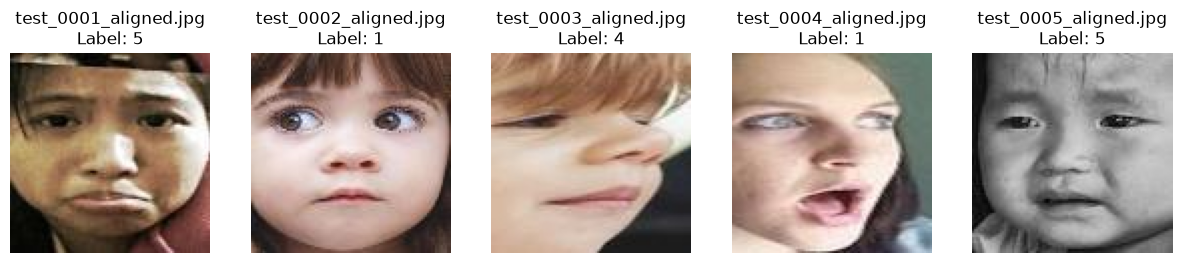

In [43]:
# first five testing records
sample = test_df.head(5)

# space for five images
figure, axes = plt.subplots(1, 5, figsize=(15, 4))

# each image with label
for axis, (_, row) in zip(axes, sample.iterrows()):
    filename = row["image"]
    label = row["label"]
    # image path
    image_path = test_folder / str(label) / filename
    image = Image.open(image_path).convert("RGB")
    # axis
    axis.imshow(image)
    axis.set_title(f"{filename}\nLabel: {label}")
    axis.axis("off")

plt.show()

**Analysis:** 

The label-file filenames accurately translate to the picture files within the appropriate per-class directories, as demonstrated by the five sample images that display correctly with their labels. Before attempting any large-scale processing, this visual check verifies that the photos are actual, real-world face shots consistent with RAF-DB's definition and validates the folder structure (test/label/filename) that the subsequent image verification phase depends on.

## 5  Mapping the Emotion Labels

Emotions are represented by the digits 1 through 7 in RAF-DB. The original numerical labels are retained for the model evaluation itself, but each value is mapped to its emotion name (Surprise, Fear, Disgust, Happiness, Sadness, Anger, Neutral) to make the distribution and evaluation results easier to read.

In [44]:
# each numerical label with its emotion name
emotion_labels = {
    1: "Surprise",
    2: "Fear",
    3: "Disgust",
    4: "Happiness",
    5: "Sadness",
    6: "Anger",
    7: "Neutral"
}

In [45]:
# emotion names
train_df["emotion"] = train_df["label"].map(emotion_labels)
test_df["emotion"] = test_df["label"].map(emotion_labels)

In [46]:
# head of training data
train_df.head()

,image,label,emotion
0,train_00001_aligned.jpg,5,Sadness
1,train_00002_aligned.jpg,5,Sadness
2,train_00003_aligned.jpg,4,Happiness
3,train_00004_aligned.jpg,4,Happiness
4,train_00005_aligned.jpg,5,Sadness


**Analysis:** 

The original numerical labels were kept with the correctly translated human-readable emotion names. This dual approach is intentional the numerical labels are still accessible for the model-scoring code, which uses class indices, but the readable names make the class-distribution and evaluation tables much easier to understand. Since the mapping is only additive, no information is lost.

## 6  Class Distribution

### 6.1  Image Counts

In order to determine whether certain emotions are significantly more common than others, which could impact both model performance and the selection of evaluation metric, the number of photos per emotion is measured for both the training and testing sets.

In [47]:
# Count images each emotion class
train_counts = train_df["emotion"].value_counts()
test_counts = test_df["emotion"].value_counts()

In [48]:
# Combine the counts into one table
class_distribution = pd.DataFrame({
    "Training Images": train_counts,
    "Testing Images": test_counts
}).fillna(0).astype(int)

In [49]:
class_distribution

,Training Images,Testing Images
emotion,,
Anger,705,162
Disgust,717,160
Fear,281,74
Happiness,4772,1185
Neutral,2524,680
Sadness,1982,478
Surprise,1290,329


### 6.2  Visualisation

The disparity between the emotion classes is clearly seen in bar charts of the training and testing distributions.

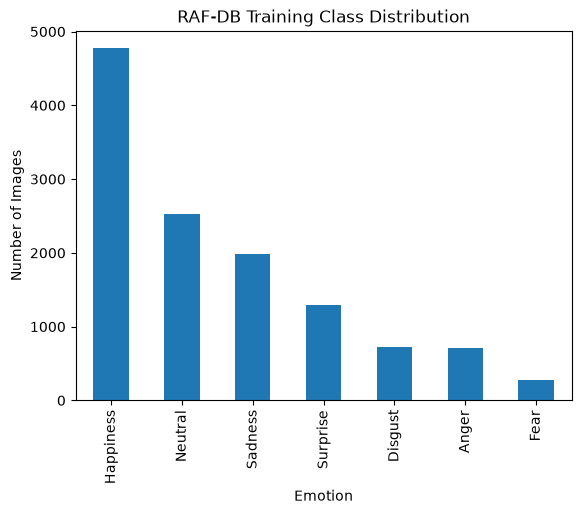

In [50]:
# bar chart for the training data
train_counts.plot(kind="bar")
plt.title("RAF-DB Training Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

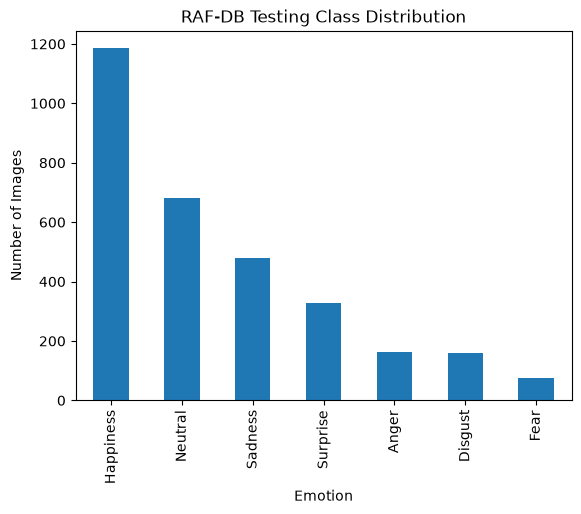

In [51]:
# bar chart for the testing data
test_counts.plot(kind="bar")
plt.title("RAF-DB Testing Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

**Analysis:** 

There is a strong imbalance in RAF-DB. There is an approximately 16-to-1 ratio between the most and least common class in the testing set Happiness dominates with 1,185 images, followed by Neutral (680) and Sadness (478). Fear is very rare with only 74 images. The same pattern can be seen in the training set (Happiness 4,772 versus Fear 281).

The evaluation design is directly and significantly impacted by this imbalance. A model may get high accuracy by simply classifying the common expressions (Happiness, Neutral) correctly while doing poorly on the uncommon ones (Fear, Disgust), and this weakness would be hidden. A straightforward accuracy score would be dominated by the huge classes. In order to avoid this, the facial-expression models are compared using macro-F1 along with per-class precision and recall. This ensures that all emotions contribute equally, regardless of how frequently they occur, and that poor performance on the uncommon classes is obvious. This is the primary methodological option driven by the investigation, and it aligns with the metric selection for the project's other imbalanced datasets.

## 7  Checking the Label Data

To make sure that incomplete or repetitive data do not skew the evaluation, the training and testing label files are examined for missing values, invalid emotion labels (outside of 1–7), and duplicate picture filenames.

In [52]:
# missing values in train_df
train_df.isnull().sum().to_frame("Missing Values")

,Missing Values
image,0
label,0
emotion,0


In [53]:
# missing values in test_df
test_df.isnull().sum().to_frame("Missing Values")

,Missing Values
image,0
label,0
emotion,0


In [54]:
# valid labels
valid_labels = [1, 2, 3, 4, 5, 6, 7]

In [55]:
# check for invalid labels train
invalid_train = train_df[~train_df["label"].isin(valid_labels)]
invalid_train

,image,label,emotion


In [56]:
# check for invalid labels test
invalid_test = test_df[~test_df["label"].isin(valid_labels)]
invalid_test

,image,label,emotion


In [57]:
# checking for duplicates in train data
train_duplicates = train_df["image"].duplicated().sum()
train_duplicates

0

In [58]:
# checking for duplicates in test data
test_duplicates = test_df["image"].duplicated().sum()
test_duplicates

0

**Analysis:** 

The label files are completely clean no missing values in any column, no invalid labels both invalid-label tables are empty, so every label lies within the expected 1-7 range, and no duplicated image filenames in either split. Each of these problems would otherwise compromise the evaluation. Duplicate filenames may double-count photos or, worse, leak an image across the train/test boundary. Missing or incorrect labels would contaminate the ground truth. The label records can be trusted and used exactly as they are, with no rows removed, because all three tests are successful.

## 8  Checking the Image Files

Beyond the labels, each image cited in the CSV files is confirmed to be a viewable, uncorrupted image that is located in the appropriate emotion folder. This makes sure that missing or unreadable files during inference time will not have an impact on the evaluation.

In [59]:
# Lists for recording image problems training data
missing_train_images = []
invalid_train_images = []

In [60]:
# Check every training image
for _, row in train_df.iterrows():
    # image path
    image_path = train_folder / str(row["label"]) / row["image"]
    # if image path does not exist
    if not image_path.exists():
        missing_train_images.append(row["image"])
    else:
        try:
            # open image and verify
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            # error 
            invalid_train_images.append(row["image"])

In [61]:
# printing statements
print("Missing training images:", len(missing_train_images))
print("Invalid training images:", len(invalid_train_images))

Missing training images: 0
Invalid training images: 0


In [62]:
# Lists for recording image problems for testing data
missing_test_images = []
invalid_test_images = []

In [63]:
# Check every testing image
for _, row in test_df.iterrows():
    image_path = test_folder / str(row["label"]) / row["image"]
    if not image_path.exists():
        missing_test_images.append(row["image"])
    else:
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            invalid_test_images.append(row["image"])

In [64]:
# printing statements
print("Missing testing images:", len(missing_test_images))
print("Invalid testing images:", len(invalid_test_images))

Missing testing images: 0
Invalid testing images: 0


**Analysis:** 

In both splits, all 12,271 training and 3,068 testing images were found in the appropriate emotion folder and successfully opened 0 missing and 0 incorrect images. In order to ensure that the vision models never come across a corrupted file during evaluation, this comprehensive file-level validation (rather than just a label-file check) verifies that every label record points to a valid, visible image. Now that this has been verified, the entire test set may be used for an in-depth evaluation and no image records need to be removed.

## 9  Checking the Image Properties

To identify what preprocessing (resizing, normalization) each candidate vision model will need, a sample of photos from various class folders is examined to determine their size, color mode, and file format information.

In [65]:
# image properties
properties = []

In [66]:
# sample paths
sample_paths = []

In [67]:
for folder in [train_folder, test_folder]:
    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            # sample path extend get the jpg pictures
            sample_paths.extend(list(class_folder.glob("*.jpg"))[:5])

In [68]:
for image_path in sample_paths:
    # open image
    with Image.open(image_path) as image:
        # append
        properties.append({
            "Width": image.width,
            "Height": image.height,
            "Colour Mode": image.mode,
            "Format": image.format
        })

In [69]:
# dataframe
df_properties = pd.DataFrame(properties)
df_properties.value_counts().reset_index(name="Number of Sample Images")

,Width,Height,Colour Mode,Format,Number of Sample Images
0,100,100,RGB,JPEG,70


**Analysis:** 

Each of the sampled images is 100x100 pixels, RGB in color, and in JPEG format, making them completely consistent. Because each vision model's preprocessing is predictable and consistent across all images, this uniformity is beneficial. Additionally, it verifies that RAF-DB offers the fixed-size, pre-aligned face cropping for which it is renowned. This notebook only characterizes the photographs, leaving the raw data unaltered, but model-specific resizing and normalization will be implemented at evaluation time because the models used subsequently have their own expected input sizes and normalization.

## 10  Conclusion

Before model evaluation, RAF-DB was investigated across all seven emotion classes. Numerical labels were mapped to readable emotion names, sample images verified the filename to image connection, and the predefined train/test split (12,271 training and 3,068 testing images) was maintained. Every linked image was verified to exist and be readable, and all sampled photos were consistent 100x100 RGB JPEGs. The label files were also checked for missing values, invalid labels, and duplicates.

The key finding was a strong class imbalance. Happiness is roughly sixteen times more common than Fear which directly motivated evaluating the facial-expression models with macro-F1 and per-class precision and recall rather than accuracy alone, so that performance on the rare emotions is not masked. No training-related processing, augmentation, or class balancing was performed because the dataset is only used to evaluate pre-trained models. Model-specific scaling and normalization will be taken care of later. No changes were made to the original RAF-DB files.

## References

[1] S. Li, W. Deng, and J. Du, "Reliable crowdsourcing and deep locality-preserving learning for expression recognition in the wild," in Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR), 2017, pp. 2852-2861. [Online]. Available: https://doi.org/10.1109/CVPR.2017.277. [Accessed: 27 June 2026].